## Homework 2: Stochastic Gradient Descent

### Exercise 2: Variance of the Stochastic Gradient (1D Experiment)

In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
N = 200
np.random.seed(0)
i = np.arange(1, N + 1)
X = i / N
eps = np.random.normal(0.0, 0.1, size=N)
Y = 2 * X + 1 + eps

In [ ]:
def L(theta, X, Y):
    theta = np.asarray(theta, dtype=float)
    return np.mean((theta[0] + theta[1] * X - Y) ** 2)

def grad_L(theta, X, Y):
    theta = np.asarray(theta, dtype=float)
    r = theta[0] + theta[1] * X - Y
    g0 = np.mean(2.0 * r)
    g1 = np.mean(2.0 * r * X)
    return np.array([g0, g1], dtype=float)

def stochastic_gradient_variance(theta, X, Y, batch_sizes, K=100, seed=42):
    rng = np.random.default_rng(seed)
    N = len(X)

    vars_dict = {}
    grads_dict = {}

    for B in batch_sizes:
        grads = np.zeros((K, 2), dtype=float)

        for k in range(K):
            idx = rng.choice(N, size=B, replace=False)
            grads[k] = grad_L(theta, X[idx], Y[idx])

        # shape (2,)
        g_bar = np.mean(grads, axis=0)
        # shape (K,2)
        diffs = grads - g_bar
        # mean of ||.||^2
        var = np.mean(np.sum(diffs**2, axis=1))

        vars_dict[B] = var
        grads_dict[B] = grads

    return vars_dict, grads_dict

In [12]:
def plot_variance_vs_batch(vars_dict, title="Empirical variance of stochastic gradient vs batch size"):
    batch_sizes = np.array(sorted(vars_dict.keys()))
    variances = np.array([vars_dict[b] for b in batch_sizes])

    plt.figure(figsize=(7,5))
    plt.plot(batch_sizes, variances, marker="o")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Batch size (log scale)")
    plt.ylabel("Empirical variance Var(g) (log scale)")
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.show()

Batch size   1: Var(g) = 3.980889e+00
Batch size   5: Var(g) = 8.750238e-01
Batch size  20: Var(g) = 2.170995e-01
Batch size 200: Var(g) = 1.582061e-29


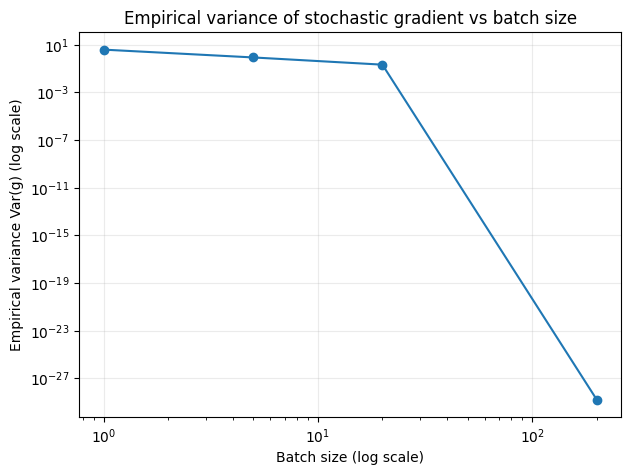

In [13]:
theta_fixed = np.array([0.0, 0.0])
batch_sizes = [1, 5, 20, N]
K = 100

vars_dict, _ = stochastic_gradient_variance(theta_fixed, X, Y, batch_sizes, K=K, seed=123)

for b in sorted(vars_dict):
    print(f"Batch size {b:>3}: Var(g) = {vars_dict[b]:.6e}")

plot_variance_vs_batch(vars_dict)